In [25]:
import difflib
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

from pathlib import Path
from tqdm import tqdm
import os

In [37]:
def partial_match_simple(predicted, target):
    predicted_parts = predicted.lower().split()
    target_parts = target.lower().split()
    return any(pred_part in target_part or target_part in pred_part for pred_part in predicted_parts for target_part in target_parts)

# Function to check for partial matches using difflib
def partial_match(predicted, target, cutoff=0.6):
    # Split the conditions into individual terms
    predicted_terms = predicted.split('|')
    target_terms = target.split('|')
    
    # Check for matches across all terms
    matches = []
    for pred in predicted_terms:
        # Use difflib to find close matches, with a cutoff for match quality
        match_found = any(difflib.get_close_matches(pred, target_terms, n=1, cutoff=cutoff))
        matches.append(match_found)
    
    # Return True if any match is found
    return any(matches)

def handle_empty_arrays(target_entities, predicted_entities):
    # Construct the results based on whether target_entities or predicted_entities are empty
    if target_entities == [''] and predicted_entities == ['']:
        return pd.Series([
            [0],  # No target entities to match against, so exact match is [0]
            [0],  # No predicted entities to match against, so exact match is [0]
            [0],  # No target entities for partial matches, so partial match is [0]
            [0]   # No predicted entities for partial matches, so partial match is [0]
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    elif target_entities == ['']:
        return pd.Series([
            [0] * len(predicted_entities),  
            [1] * len(predicted_entities),  
            [0] * len(predicted_entities), 
            [1] * len(predicted_entities)  
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    # Handle case where predicted_entities is empty, if required
    else: # predicted_entities == ['']:
        return pd.Series([
            [1] * len(target_entities), 
            [0] * len(target_entities),  
            [1] * len(target_entities),  
            [0] * len(target_entities)   
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])

# Function to compute exact and partial annotations for predicted and target conditions
def compute_annotations(row, entity, model):

    target_col = f'unique_{entity.replace("_v1","").replace("_v2","")}_target'
    model_col = f'unique_{entity}_{model}'
    
    # --- Parse and lowercase ---
    target_entities = (
        [] if pd.isna(row[target_col]) or str(row[target_col]).strip() == ""
        else [e.strip().lower() for e in str(row[target_col]).split('|') if len(e.strip()) > 2]
    )

    predicted_entities = (
        [] if pd.isna(row[model_col]) or str(row[model_col]).strip() == ""
        else [e.strip().lower() for e in str(row[model_col]).split('|') if len(e.strip()) > 2]
    )

    if not target_entities or not predicted_entities:
        return handle_empty_arrays(target_entities, predicted_entities)

    # Create a set of all unique entities from both target and predicted for consistent indexing
    all_entities = set(target_entities + predicted_entities)

    # Target annotations (exact)
    target_annotations_exact = [1 if entity in target_entities else 0 for entity in all_entities]

    # Predicted annotations (exact)
    predicted_annotations_exact = [1 if entity in predicted_entities else 0 for entity in all_entities]

    # Target annotations (partial)
    target_annotations_partial = [1 if any(partial_match(entity, target_ent) for target_ent in target_entities) else 0 for entity in all_entities]

    # Predicted annotations (partial)
    predicted_annotations_partial = [1 if any(partial_match(entity, pred) for pred in predicted_entities) else 0 for entity in all_entities]

    return pd.Series([
        target_annotations_exact,
        predicted_annotations_exact,
        target_annotations_partial,
        predicted_annotations_partial
    ], index=[
        f'target_{entity}_annotations_exact_{model}',
        f'predicted_{entity}_annotations_exact_{model}',
        f'target_{entity}_annotations_partial_{model}',
        f'predicted_{entity}_annotations_partial_{model}'
    ])



In [3]:
prompt_id = "prompt5_32B_FS"
batch_id = "batch_1"
predictions_subset = pd.read_csv(f"./bert_ner_predictions/llm_cleaned/llm_disease_{batch_id}_{prompt_id}.csv")
predictions_subset.head()

,doc_id,unique_conditions_biolinkbert,unique_interventions_biolinkbert,Text,unique_conditions_target,unique_interventions_target,unique_conditions_biolinkbert_llm_clean_prompt5_32B_FS
0,My_pdf764_title^abstract,neuropathic pain,sirt1|resveratrol|ly|inhibitor of sirtuin 1|re...,Resveratrol inhibits paclitaxel-induced neurop...,neuropathic pain,ex-527|ly294002|resveratrol|res,neuropathic pain
1,My_pdf268new_title^abstract,neuropathic pain,sap|ib (4)-saporin conjugate|ib (4)-sap|ib4-sa...,The behavioral and neuroanatomical effects of ...,neuropathic pain,ib4-saporin|ib(4)-saporin|ib(4)-sap,neuropathic pain
2,My_pdf379new_title^abstract,visceral hypersensitivity|gastric|gastric hype...,5-ht2a antagonist|ketanserin|dvs|serotonin and...,Desvenlafaxine succinate ameliorates visceral ...,visceral hypersensitivity|gastric hyperalgesia...,5-ht1a antagonist|dvs|serotonin and norepineph...,visceral hypersensitivity|gastric hyperalgesia
3,My_pdf693_title^abstract,spinal cord injury|spinal cord|aortic occlusio...,nicotinamide,Ischemic preconditioning and nicotinamide in s...,spinal cord injury|transient aortic occlusion,nicotinamide,spinal cord injury|aortic occlusion|transient ...
4,My_pdf856_title^abstract,hypoxia -|hypoxia|seizures|perinatal hypoxic e...,excitatory amino acid antagonists mk-801|lzp|i...,NBQX blocks acute and late epileptogenic effec...,perinatal hypoxia|hypoxia|seizures|perinatal h...,mk-801|excitatory amino acid antagonists|6-nit...,hypoxia|seizures|perinatal hypoxic encephalopa...


In [9]:
def flatten_column_arrays(column):
    # Prepare an array to hold the actual arrays/lists
    prepared_arrays = []
    
    for item in column:
        if isinstance(item, str):
            try:
                # Safely evaluate the string to see if it represents a list
                evaluated_item = ast.literal_eval(item)
                if isinstance(evaluated_item, list):
                    prepared_arrays.append(np.array(evaluated_item))
            except (SyntaxError, ValueError):
                # If evaluation fails or it's not a list, skip or handle non-list string
                print("Not possible to flatten ", item)
                continue
        elif isinstance(item, list):
            prepared_arrays.append(np.array(item))
        elif isinstance(item, np.ndarray):
            prepared_test_arrays.append(item)
    
    if prepared_arrays:
        # Concatenate all arrays in the list and then flatten the result
        return np.concatenate(prepared_arrays).flatten()
    else:
        return np.array([])  # Return an empty array if no valid arrays were found

def round_tuple(x, decimals=2):
    """
    Recursively round elements of a tuple.
    If x is a scalar (int/float), return the rounded value directly.
    """
    if isinstance(x, (int, float)):
        return round(x, decimals)
    elif isinstance(x, tuple):
        return tuple(round_tuple(item, decimals) for item in x)
    else:
        raise TypeError(f"Unsupported type {type(x)} for round_tuple")

In [10]:
def calculate_exact_and_partial_match_scores(annotations_df, entities, models, round_to=2):
    exact_matches = {}
    partial_matches = {}
    scores = {}
    for entity in entities:
        exact_matches[entity] = {}
        partial_matches[entity] = {}
        scores[entity] = {}
    
        for model in models:
            if (entity != 'condition' and entity != 'drug') and 'regex' in model:
               continue  
            #try:
            # Check if all columns are present in the DataFrame
            # Columns to check
            columns_to_check = [f'target_{entity}_annotations_exact_{model}',
                                f'predicted_{entity}_annotations_exact_{model}',
                                f'target_{entity}_annotations_partial_{model}',
                                f'predicted_{entity}_annotations_partial_{model}']
            
            # Check if all columns are present in the DataFrame
            missing_columns = [col for col in columns_to_check if col not in annotations_df.columns]
            if not missing_columns:
                flattened_data_target_exact = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_exact_{model}'])
                flattened_data_model_exact = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_exact_{model}'])
                flattened_data_target_partial = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_partial_{model}'])
                flattened_data_model_partial = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_partial_{model}'])
            else:
                # Handle the case where one or more columns are missing
                print("The following required columns are missing in the DataFrame:")
                for col in missing_columns:
                    print(col)
    
            flattened_data_target_exact = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_model_exact = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_target_partial = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_partial_{model}', pd.Series()))
            flattened_data_model_partial = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_partial_{model}', pd.Series()))

            # Calculate and store F1 scores
            exact_f1 = f1_score(flattened_data_target_exact, flattened_data_model_exact, average='binary')
            print(exact_f1)
            partial_f1 = f1_score(flattened_data_target_partial, flattened_data_model_partial, average='binary')

            exact_precision = precision_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_precision = precision_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_recall = recall_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_recall = recall_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_matches[entity][model] = round_tuple(exact_f1,round_to)
            partial_matches[entity][model] = round_tuple(partial_f1,round_to)

            scores[entity][model] = {
                "exact": {
                    "precision": round_tuple(exact_precision, round_to),
                    "recall": round_tuple(exact_recall, round_to),
                    "f1": round_tuple(exact_f1, round_to),
                },
                "partial": {
                    "precision": round_tuple(partial_precision, round_to),
                    "recall": round_tuple(partial_recall, round_to),
                    "f1": round_tuple(partial_f1, round_to),
                }
            }
    
           # except Exception as e:
            #    print(f"An error occurred for {model} in {entity}: {e}")
    return exact_matches, partial_matches, scores

In [18]:
def scores_to_table(results_dict, entity_name="conditions"):
    rows = []
    for model, match_types in results_dict[entity_name].items():
        for match_type, scores in match_types.items():
            for metric, value in scores.items():
                row_key = f"{entity_name}_{match_type}_{metric}"
                rows.append({"metric": row_key, "model": model, "value": value})
    
    df = pd.DataFrame(rows)
    table = df.pivot(index="metric", columns="model", values="value")
    return table

In [11]:
models

['biolinkbert', 'biolinkbert_llm_clean_prompt5_32B_FS']

In [15]:
prompt_id = "prompt5_32B_FS"
batch_id = "batch_0"

# List of entity types and models based on your dataframe structure
entities = ['conditions']
models = ['biolinkbert', f'biolinkbert_llm_clean_{prompt_id}']#, 'biobert-v1.1', 'bert-base-uncased', 'aact']

predictions_subset = pd.read_csv(f"./bert_ner_predictions/llm_cleaned/llm_disease_{batch_id}_{prompt_id}.csv")

# Apply the annotation functions to each row for each entity-model combination
for entity in entities:
    for model in models:
        annotations_cols = [
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ]
        predictions_subset[annotations_cols] = predictions_subset.apply(lambda row: compute_annotations(row, entity, model), axis=1)
predictions_subset.head()

,doc_id,unique_conditions_biolinkbert,unique_interventions_biolinkbert,Text,unique_conditions_target,unique_interventions_target,unique_conditions_biolinkbert_llm_clean_prompt5_32B_FS,target_conditions_annotations_exact_biolinkbert,predicted_conditions_annotations_exact_biolinkbert,target_conditions_annotations_partial_biolinkbert,predicted_conditions_annotations_partial_biolinkbert,target_conditions_annotations_exact_biolinkbert_llm_clean_prompt5_32B_FS,predicted_conditions_annotations_exact_biolinkbert_llm_clean_prompt5_32B_FS,target_conditions_annotations_partial_biolinkbert_llm_clean_prompt5_32B_FS,predicted_conditions_annotations_partial_biolinkbert_llm_clean_prompt5_32B_FS
0,My_pdf953_title^abstract,neuropathic pain,pregabalin,Ameliorative potential of Alstonia scholaris (...,peripheral neuropathy|neuropathic pain,chloroform|pregabalin,neuropathic pain,"[1, 1]","[1, 0]","[1, 1]","[1, 0]","[1, 1]","[1, 0]","[1, 1]","[1, 0]"
1,My_pdf378new_title^abstract,persistent pain|neuropathic pain,12-lipoxygenase inhibitor|baicalein,Baicalein attenuates neuropathic pain and impr...,neuropathic pain,12-lipoxygenase inhibitor|baicalein,neuropathic pain,"[1, 0]","[1, 1]","[1, 0]","[1, 1]",[1],[1],[1],[1]
2,My_pdf810_title^abstract,aneurysm|aneurysms|intracranial aneurysms,NaN,In situ tissue engineering: endothelial growth...,aneurysms|intracranial aneurysms,NaN,aneurysm|aneurysms|intracranial aneurysms,"[0, 1, 1]","[1, 1, 1]","[1, 1, 1]","[1, 1, 1]","[0, 1, 1]","[1, 1, 1]","[1, 1, 1]","[1, 1, 1]"
3,My_pdf680_title^abstract,traumatic spinal cord injury,NaN,Bridging a complete transection lesion of adul...,traumatic spinal cord injury,NaN,traumatic spinal cord injury,[1],[1],[1],[1],[1],[1],[1],[1]
4,My_pdf509new_title^abstract,malignant glioma|glioma|intracranial gliomas,monoclonal antibodies|anti-ctla-4 monoclonal a...,Sequential immunotherapy by vaccination with G...,malignant glioma|intracranial tumors|intracran...,anti-ctla-4 monoclonal antibodies|ctla-4 block...,malignant glioma|glioma|intracranial gliomas,"[0, 1, 1, 1]","[1, 1, 1, 0]","[0, 1, 1, 1]","[1, 1, 1, 1]","[0, 1, 1, 1]","[1, 1, 1, 0]","[0, 1, 1, 1]","[1, 1, 1, 1]"


In [16]:
exact_matches, partial_matches, scores = calculate_exact_and_partial_match_scores(predictions_subset, entities, models)
scores

0.6983050847457628
0.7306273062730627


{'conditions': {'biolinkbert': {'exact': {'precision': 0.68,
    'recall': 0.72,
    'f1': 0.7},
   'partial': {'precision': 0.8, 'recall': 0.84, 'f1': 0.81}},
  'biolinkbert_llm_clean_prompt5_32B_FS': {'exact': {'precision': 0.77,
    'recall': 0.69,
    'f1': 0.73},
   'partial': {'precision': 0.89, 'recall': 0.81, 'f1': 0.85}}}}

In [17]:
table = scores_to_table(scores, "conditions")
table

model,biolinkbert,biolinkbert_llm_clean_prompt5_32B_FS
metric,,
conditions_exact_f1,0.70,0.73
conditions_exact_precision,0.68,0.77
conditions_exact_recall,0.72,0.69
conditions_partial_f1,0.81,0.85
conditions_partial_precision,0.80,0.89
conditions_partial_recall,0.84,0.81


In [19]:
prompt_id = "prompt1_32B_FS_LLM_ONLY"
batch_id = "batch_0"

# List of entity types and models based on your dataframe structure
entities = ['conditions']
models = ['biolinkbert', f'LLM_extractor_{prompt_id}']#, 'biobert-v1.1', 'bert-base-uncased', 'aact']

predictions_subset = pd.read_csv(f"./bert_ner_predictions/llm_cleaned/llm_conditions_{batch_id}_{prompt_id}.csv")

# Apply the annotation functions to each row for each entity-model combination
for entity in entities:
    for model in models:
        annotations_cols = [
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ]
        predictions_subset[annotations_cols] = predictions_subset.apply(lambda row: compute_annotations(row, entity, model), axis=1)
predictions_subset.head()

,doc_id,unique_conditions_biolinkbert,unique_interventions_biolinkbert,Text,unique_conditions_target,unique_interventions_target,unique_conditions_LLM_extractor_prompt1_32B_FS_LLM_ONLY,target_conditions_annotations_exact_biolinkbert,predicted_conditions_annotations_exact_biolinkbert,target_conditions_annotations_partial_biolinkbert,predicted_conditions_annotations_partial_biolinkbert,target_conditions_annotations_exact_LLM_extractor_prompt1_32B_FS_LLM_ONLY,predicted_conditions_annotations_exact_LLM_extractor_prompt1_32B_FS_LLM_ONLY,target_conditions_annotations_partial_LLM_extractor_prompt1_32B_FS_LLM_ONLY,predicted_conditions_annotations_partial_LLM_extractor_prompt1_32B_FS_LLM_ONLY
0,My_pdf953_title^abstract,neuropathic pain,pregabalin,Ameliorative potential of Alstonia scholaris (...,peripheral neuropathy|neuropathic pain,chloroform|pregabalin,neuropathic pain|chronic constriction injury|p...,"[1, 1]","[1, 0]","[1, 1]","[1, 0]","[1, 0, 1]","[1, 1, 1]","[1, 0, 1]","[1, 1, 1]"
1,My_pdf378new_title^abstract,persistent pain|neuropathic pain,12-lipoxygenase inhibitor|baicalein,Baicalein attenuates neuropathic pain and impr...,neuropathic pain,12-lipoxygenase inhibitor|baicalein,neuropathic pain|sciatic nerve function recovery,"[1, 0]","[1, 1]","[1, 0]","[1, 1]","[1, 0]","[1, 1]","[1, 0]","[1, 1]"
2,My_pdf810_title^abstract,aneurysm|aneurysms|intracranial aneurysms,NaN,In situ tissue engineering: endothelial growth...,aneurysms|intracranial aneurysms,NaN,intracranial aneurysms,"[0, 1, 1]","[1, 1, 1]","[1, 1, 1]","[1, 1, 1]","[1, 1]","[0, 1]","[1, 1]","[0, 1]"
3,My_pdf680_title^abstract,traumatic spinal cord injury,NaN,Bridging a complete transection lesion of adul...,traumatic spinal cord injury,NaN,spinal cord injury|traumatic spinal cord injury,[1],[1],[1],[1],"[0, 1]","[1, 1]","[1, 1]","[1, 1]"
4,My_pdf509new_title^abstract,malignant glioma|glioma|intracranial gliomas,monoclonal antibodies|anti-ctla-4 monoclonal a...,Sequential immunotherapy by vaccination with G...,malignant glioma|intracranial tumors|intracran...,anti-ctla-4 monoclonal antibodies|ctla-4 block...,malignant glioma|glioma,"[0, 1, 1, 1]","[1, 1, 1, 0]","[0, 1, 1, 1]","[1, 1, 1, 1]","[0, 1, 1, 1]","[1, 0, 1, 0]","[0, 1, 1, 1]","[1, 0, 1, 0]"


In [20]:
exact_matches, partial_matches, scores = calculate_exact_and_partial_match_scores(predictions_subset, entities, models)
table = scores_to_table(scores, "conditions")
table

0.6983050847457628
0.5163636363636364


model,LLM_extractor_prompt1_32B_FS_LLM_ONLY,biolinkbert
metric,,
conditions_exact_f1,0.52,0.70
conditions_exact_precision,0.54,0.68
conditions_exact_recall,0.50,0.72
conditions_partial_f1,0.74,0.81
conditions_partial_precision,0.75,0.80
conditions_partial_recall,0.73,0.84


### all CV subsets

In [21]:
predictions_subset.columns

Index(['doc_id', 'unique_conditions_biolinkbert',
       'unique_interventions_biolinkbert', 'Text', 'unique_conditions_target',
       'unique_interventions_target',
       'unique_conditions_LLM_extractor_prompt1_32B_FS_LLM_ONLY',
       'target_conditions_annotations_exact_biolinkbert',
       'predicted_conditions_annotations_exact_biolinkbert',
       'target_conditions_annotations_partial_biolinkbert',
       'predicted_conditions_annotations_partial_biolinkbert',
       'target_conditions_annotations_exact_LLM_extractor_prompt1_32B_FS_LLM_ONLY',
       'predicted_conditions_annotations_exact_LLM_extractor_prompt1_32B_FS_LLM_ONLY',
       'target_conditions_annotations_partial_LLM_extractor_prompt1_32B_FS_LLM_ONLY',
       'predicted_conditions_annotations_partial_LLM_extractor_prompt1_32B_FS_LLM_ONLY'],
      dtype='object')

In [43]:
PROMPT_MAIN = "prompt5_32B_FS"
PROMPT_LLM_ONLY = "prompt1_32B_FS_LLM_ONLY"
ENTITIES = ["conditions"]
BASE_MODELS = ["biolinkbert", f"biolinkbert_llm_clean_{PROMPT_MAIN}"]

IN_DIR = Path("./bert_ner_predictions/llm_cleaned")
OUT_DIR = IN_DIR / "with_arrays"
OUT_DIR.mkdir(parents=True, exist_ok=True)

tqdm.pandas()

def apply_annotations(df, entity, model):
    cols = [f"target_{entity}_annotations_exact_{model}",
            f"predicted_{entity}_annotations_exact_{model}",
            f"target_{entity}_annotations_partial_{model}",
            f"predicted_{entity}_annotations_partial_{model}"]
    df[cols] = df.progress_apply(
        lambda r: pd.Series((list(compute_annotations(r, entity, model)) + ["", "", "", ""])[:4]),
        axis=1, result_type="expand"
    )
    return df

def save_subset(df, batch_id, entity, kind, models, prompt=PROMPT_MAIN):
    base_cols = ["doc_id", f"unique_{entity}_target", f"unique_{entity}_biolinkbert",
                 f"unique_{entity}_biolinkbert_llm_clean_{prompt}", "unique_conditions_LLM_extractor_prompt1_32B_FS_LLM_ONLY"]
    ann_cols = [f"{t}_{entity}_annotations_{kind}_{m}" for m in models for t in ["target","predicted"]]
    cols = [c for c in base_cols + ann_cols if c in df.columns]
    df.loc[:, cols].to_csv(OUT_DIR / f"{batch_id}_{entity}_{kind}.csv", index=False)

batch_results = {}
for i in range(10):
    batch_id = f"batch_{i}"
    f_main = IN_DIR / f"llm_disease_{batch_id}_{PROMPT_MAIN}.csv"
    if not f_main.exists():
        print(f"[SKIP] {batch_id}")
        continue

    df = pd.read_csv(f_main)
    models = BASE_MODELS.copy()

    for e in ENTITIES:
        # Base models on df
        for m in models:
            apply_annotations(df, e, m)

        # LLM-only: compute on llm_df, merge by doc_id
        if e == "conditions":
            f_llm = IN_DIR / f"llm_conditions_{batch_id}_{PROMPT_LLM_ONLY}.csv"
            if f_llm.exists():
                m_llm = f"LLM_extractor_{PROMPT_LLM_ONLY}"
                llm_df = pd.read_csv(f_llm)
                tmp = llm_df.progress_apply(
                    lambda r: pd.Series((list(compute_annotations(r, e, m_llm)) + ["", "", "", ""])[:4]),
                    axis=1, result_type="expand"
                )
                tmp.columns = [
                    f"target_{e}_annotations_exact_{m_llm}",
                    f"predicted_{e}_annotations_exact_{m_llm}",
                    f"target_{e}_annotations_partial_{m_llm}",
                    f"predicted_{e}_annotations_partial_{m_llm}",
                ]
                df = df.merge(pd.concat([llm_df[["doc_id", "unique_conditions_LLM_extractor_prompt1_32B_FS_LLM_ONLY"]], tmp], axis=1), on="doc_id", how="left")
                models.append(m_llm)
            else:
                print(f"[WARN] {batch_id}: missing {f_llm.name}")

        save_subset(df, batch_id, e, "partial", models)
        save_subset(df, batch_id, e, "exact", models)

    _, _, scores = calculate_exact_and_partial_match_scores(df, ENTITIES, models)
    batch_results[batch_id] = scores

100%|██████████| 69/69 [00:00<00:00, 1931.40it/s]


0.6983050847457628
0.7306273062730627
0.6181818181818182


100%|██████████| 67/67 [00:00<00:00, 1849.49it/s]


0.6490066225165564
0.6836363636363636
0.5813148788927337


100%|██████████| 74/74 [00:00<00:00, 1833.81it/s]


...

0.6561514195583595
0.6551724137931035
0.6488294314381272


100%|██████████| 68/68 [00:00<00:00, 1880.78it/s]


0.6954022988505748
0.6967741935483871
0.6274509803921569


100%|██████████| 70/70 [00:00<00:00, 1897.09it/s]


0.6266666666666667
0.6319444444444444
0.5570469798657718


In [39]:
def make_results_table(results_dict, metric_type='exact', entity='conditions', include_mean_std=True):
    """
    Create a comparison table of precision, recall, and f1 scores for each model and batch.
    
    Parameters
    ----------
    results_dict : dict
        Dictionary like your example.
    metric_type : str
        Either 'exact' or 'partial'.
    include_mean_std : bool
        Whether to append mean ± std rows.
    
    Returns
    -------
    pd.DataFrame
        A tidy comparison table.
    """
    rows = []
    
    for batch_name, batch_data in results_dict.items():
        for model_name, metrics in batch_data[entity].items():
            row = {
                'Batch': batch_name,
                'Model': model_name,
                'Precision': metrics[metric_type]['precision'],
                'Recall': metrics[metric_type]['recall'],
                'F1': metrics[metric_type]['f1']
            }
            rows.append(row)
    
    df = pd.DataFrame(rows)
    df = df.sort_values(['Model', 'Batch']).reset_index(drop=True)
    
    if include_mean_std:
        summary_rows = []
        for model in df['Model'].unique():
            model_df = df[df['Model'] == model]
            mean_row = {
                'Batch': 'Mean',
                'Model': model,
                'Precision': model_df['Precision'].mean(),
                'Recall': model_df['Recall'].mean(),
                'F1': model_df['F1'].mean()
            }
            std_row = {
                'Batch': 'Std',
                'Model': model,
                'Precision': model_df['Precision'].std(),
                'Recall': model_df['Recall'].std(),
                'F1': model_df['F1'].std()
            }
            summary_rows.extend([mean_row, std_row])
        df = pd.concat([df, pd.DataFrame(summary_rows)], ignore_index=True)
    
    return df


In [40]:
make_results_table(batch_results, metric_type='exact', entity='conditions')

,Batch,Model,Precision,Recall,F1
0,batch_0,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.640000,0.590000,0.620000
1,batch_1,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.580000,0.580000,0.580000
2,batch_2,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.690000,0.500000,0.580000
3,batch_3,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.610000,0.580000,0.600000
4,batch_4,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.690000,0.540000,0.610000
5,batch_5,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.670000,0.480000,0.560000
6,batch_6,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.760000,0.540000,0.630000
7,batch_7,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.710000,0.600000,0.650000
8,batch_8,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.720000,0.560000,0.630000
9,batch_9,LLM_extractor_prompt1_32B_FS_LLM_ONLY,0.620000,0.510000,0.560000


In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(results_dict, metric_type='exact', entity='conditions'):
    """
    Plot precision, recall, and f1 scores for each model across batches.
    
    Parameters
    ----------
    results_dict : dict
        Dictionary of results (like your example).
    metric_type : str
        Either 'exact' or 'partial' — which metric subset to visualize.
    """
    
    models = list(next(iter(results_dict.values()))[entity].keys())
    metrics = ['precision', 'recall', 'f1']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    x_positions = np.arange(len(metrics))  # precision, recall, f1
    markers = {'dot': 'o', 'mean': 'D'}   # D = diamond
    
    for model_idx, model in enumerate(models):
        color = f"C{model_idx}"
        # Collect per-batch metric values
        model_values = {m: [] for m in metrics}
        
        for batch_data in results_dict.values():
            cond = batch_data[entity][model][metric_type]
            for m in metrics:
                model_values[m].append(cond[m])
        
        # Plot individual batch dots
        for i, m in enumerate(metrics):
            y_vals = model_values[m]
            ax.scatter(
                [x_positions[i] + model_idx*0.1 - 0.05]*len(y_vals),
                y_vals,
                label=f"{model}" if i == 0 else "",
                color=color,
                alpha=0.6,
                marker=markers['dot']
            )
        
        # Plot mean diamond
        means = [np.mean(model_values[m]) for m in metrics]
        ax.scatter(
            x_positions + model_idx*0.1 - 0.05,
            means,
            color=color,
            edgecolor='black',
            s=120,
            marker=markers['mean']
        )
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels([m.capitalize() for m in metrics], fontsize=15)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='y', labelsize=15)
    ax.set_ylabel("Score", fontsize=15)
    ax.set_title(f"Model Comparison for {entity.title()} ({metric_type.capitalize()} Metrics)", fontsize=15)
    ax.legend(title="Model", fontsize=13, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig(f"viz/{entity}_{metric_type}.pdf")
    plt.show()

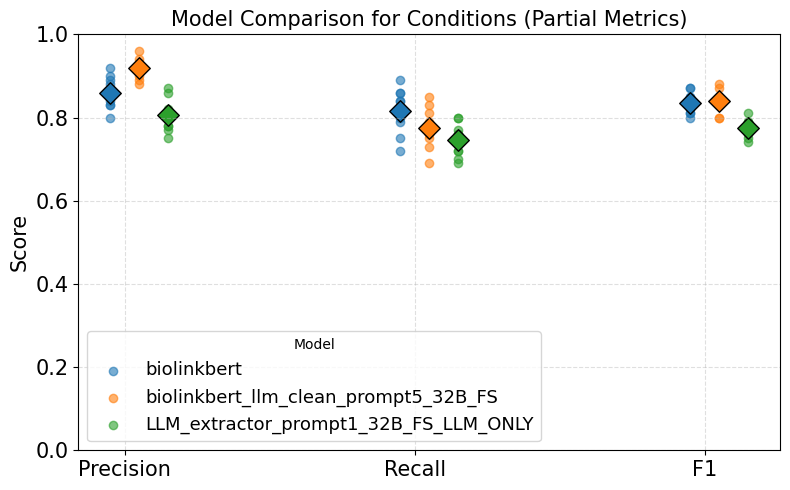

In [42]:
plot_model_comparison(batch_results, metric_type='partial', entity='conditions')
